## A&B Testing

Generate Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000  # users per group

# Create user IDs and group labels
control = pd.DataFrame({'user_id': range(1, n+1), 'group': 'control'})
treatment = pd.DataFrame({'user_id': range(n+1, 2*n+1), 'group': 'treatment'})

# Simulate conversions (binomial)
p_control = 0.12
p_treatment = 0.14

control['converted'] = np.random.binomial(1, p_control, n)
treatment['converted'] = np.random.binomial(1, p_treatment, n)

# Simulate order values for converted users (log-normal distribution, realistic)
control.loc[control['converted'] == 1, 'order_value'] = np.random.lognormal(mean=3.5, sigma=0.5, size=(control['converted'] == 1).sum()).round(2)
treatment.loc[treatment['converted'] == 1, 'order_value'] = np.random.lognormal(mean=3.6, sigma=0.5, size=(treatment['converted'] == 1).sum()).round(2)

# Fill non-converted order_value with 0
control['order_value'] = control['order_value'].fillna(0)
treatment['order_value'] = treatment['order_value'].fillna(0)

# Combine into one dataframe
ab_data = pd.concat([control, treatment], ignore_index=True)

# Save to CSV (optional)
ab_data.to_csv('ab_test_data.csv', index=False)

# Preview
ab_data.head()

,user_id,group,converted,order_value
0,1,control,0,0.00
1,2,control,1,15.74
2,3,control,0,0.00
3,4,control,0,0.00
4,5,control,0,0.00


In [3]:
df = pd.read_csv('ab_test_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      10000 non-null  int64  
 1   group        10000 non-null  str    
 2   converted    10000 non-null  int64  
 3   order_value  10000 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 312.6 KB


In [6]:
df.isnull().sum()

user_id        0
group          0
converted      0
order_value    0
dtype: int64

In [7]:
df['group'].value_counts()

group
control      5000
treatment    5000
Name: count, dtype: int64

In [8]:
df.groupby('group')['converted'].mean()

group
control      0.1156
treatment    0.1326
Name: converted, dtype: float64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

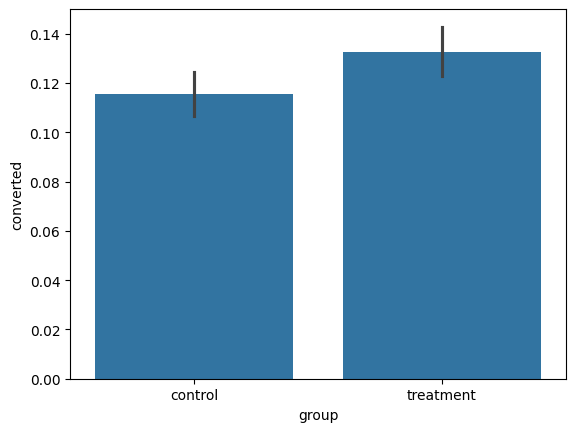

In [11]:
sns.barplot(x='group', y='converted', data=df);

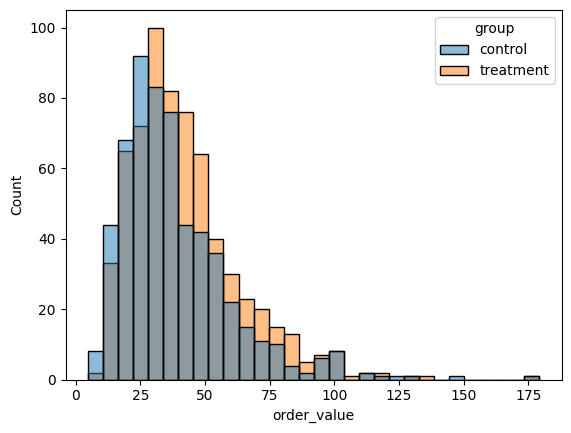

In [ ]:
sns.histplot(x='order_value', hue='group', data=df[df['converted'] == 1], bins=30, );

In [16]:
!pip install scipy


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from scipy import stats

# Number of users in each group
n_control = (ab_data['group'] == 'control').sum()
n_treatment = (ab_data['group'] == 'treatment').sum()

# Number of conversions in each group
conv_control = ab_data[ab_data['group'] == 'control']['converted'].sum()
conv_treatment = ab_data[ab_data['group'] == 'treatment']['converted'].sum()

# Observed conversion rates
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

# Pooled probability (assuming H0: no difference)
p_pool = (conv_control + conv_treatment) / (n_control + n_treatment)

# Standard error under H0
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_treatment))

# Z-statistic
z = (p_treatment - p_control) / se_pool

# Two-tailed p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Control conversion: {p_control:.4f}")
print(f"Treatment conversion: {p_treatment:.4f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {p_value:.4f}")

Control conversion: 0.1156
Treatment conversion: 0.1326
Z-statistic: 2.5781
P-value: 0.0099
